In [ ]:
prompt = """
Analyze this mirror selfie for a digital wardrobe.

Identify every clearly visible clothing and footwear item being worn by the person.

For every item, return:

- category
- type: top, bottom, outerwear, footwear, accessory
- primary_color (in hex)
- secondary_color (in hex)
- pattern
- confidence
- bounding_box

The bounding_box must be provided as:

[ymin, xmin, ymax, xmax]

Coordinates must be normalized from 0 to 1000.

The bounding box should tightly surround the clothing item itself.
Do not include unnecessary background, the mirror, the phone, or unrelated body parts where possible.

Only identify clothing and footwear that are actually being worn.

Do not identify:
- the person
- skin
- hair
- mirror
- phone
- furniture
- walls
- background objects

If an item is partially obscured but clearly identifiable, include it and reduce the confidence score accordingly.

Do not invent items that cannot be clearly seen.

Return ONLY valid JSON in exactly this format (no need to wrap in a JSON markdown code bloc, just the plain text):

{
  "items": [
    {
      "category": "hoodie",
      "type": "top",
      "primary_color": "black",
      "secondary_color": null,
      "pattern": "plain",
      "confidence": 0.95,
      "bounding_box": [200, 300, 550, 700]
    }
  ]
}
"""

In [3]:
import os
import json
from google import genai
from google.genai import types
client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

def analyze_outfit(image_path: str):
    try:
        with open(image_path, "rb") as image_file:
            response = client.models.generate_content(
                model="gemini-3.5-flash",
                contents=[
                    types.Part.from_text(text=prompt),
                    types.Part.from_bytes(
                        data=image_file.read(),
                        mime_type="image/jpeg"
                    )
                ],
            )

        return json.loads(response.text)
    except Exception as error:
        return {"error": str(error)}

/Users/guestuser/Documents/Projects/what-do-i-wear-today/.venv/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/guestuser/Documents/Projects/what-do-i-wear-today/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/guestuser/Documents/Projects/what-do-i-wear-today/.venv/lib/python3.9/site-packages/google/oauth2/__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-e

In [4]:
image_path = "/Users/guestuser/Documents/Projects/what-do-i-wear-today/experiments/test-images/test_1.png"

In [5]:
result = analyze_outfit(image_path)

In [6]:
res = json.dumps(result, indent=2)

In [7]:
# TODO: Plot boxes on image and extract whats inside the ihe bounded box

In [12]:
res = json.loads(res)

In [24]:
items = [i for i in res["items"]]
print(items, len(items))

[{'category': 'shirt', 'type': 'top', 'primary_color': 'blue', 'secondary_color': None, 'pattern': 'plain', 'confidence': 0.98, 'bounding_box': [338, 0, 778, 647]}, {'category': 'pants', 'type': 'bottom', 'primary_color': 'black', 'secondary_color': None, 'pattern': 'plain', 'confidence': 0.95, 'bounding_box': [724, 126, 1000, 568]}, {'category': 'glasses', 'type': 'accessory', 'primary_color': 'grey', 'secondary_color': None, 'pattern': 'plain', 'confidence': 0.9, 'bounding_box': [275, 185, 332, 364]}] 3


In [25]:
import cv2

In [27]:
def plot_boxes(image_path: str, items_list: list):
    for item in items_list:
        image = cv2.imread(image_path)
        ymin, xmin, ymax, xmax = item['bounding_box']
        start_point = (xmin, ymin)
        end_point = (xmax, ymax)
        color = (0, 255, 0)
        thickness = 2
        cv2.rectangle(image, start_point, end_point, color, thickness)

    return image

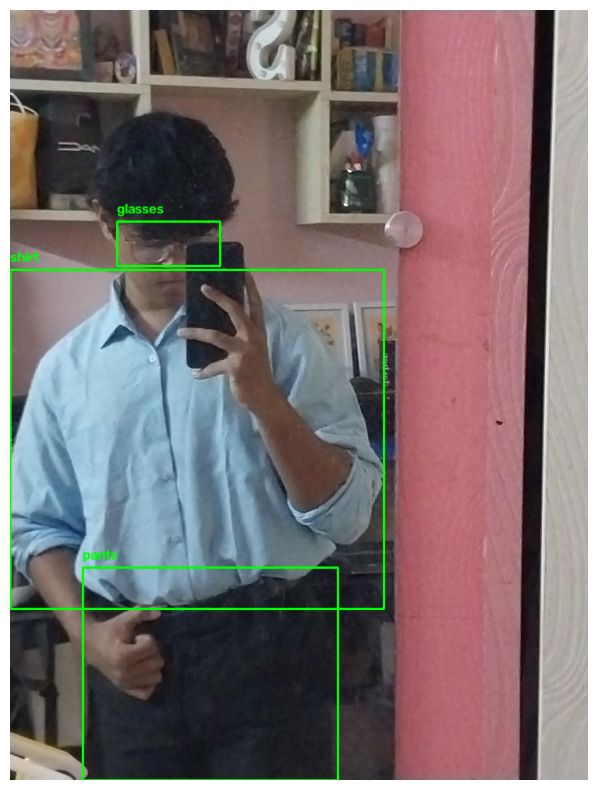

In [29]:
import matplotlib.pyplot as plt

def plot_boxes(image_path: str, items_list: list):
    image = cv2.imread(image_path)
    height, width = image.shape[:2]

    for item in items_list:
        ymin, xmin, ymax, xmax = item["bounding_box"]

        # Convert normalized 0–1000 coordinates to pixel coordinates
        x1 = int(xmin / 1000 * width)
        y1 = int(ymin / 1000 * height)
        x2 = int(xmax / 1000 * width)
        y2 = int(ymax / 1000 * height)

        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            image,
            item["category"],
            (x1, max(y1 - 10, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2,
        )

    return image

boxed_image = plot_boxes(image_path, items)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(boxed_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()